### Read Data and Import Necessary Libraries

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

conn = sqlite3.connect("../raw_data/sf_data.db")

query = "SELECT * FROM guild_tracking WHERE stat_type = 'Level'"
level_raw_data_df = pd.read_sql_query(query, conn)

conn.close()

### Level Progress

In [2]:
target_month = "2026-06"  # yyyy-mm

level_raw_data_df = level_raw_data_df.drop_duplicates(subset=['player_name', 'timestamp'])
level_raw_data_df['timestamp'] = pd.to_datetime(level_raw_data_df['timestamp'])
pivot_df = level_raw_data_df.pivot(index='player_name', columns='timestamp', values='value')
weeks = sorted(pivot_df.columns)

last_level_col = None
for week in weeks:
    if week.strftime('%Y-%m') == target_month:
        last_level_col = week

if last_level_col is None:
    raise ValueError(f"Keine Daten für Monat {target_month} gefunden.")

pivot_df_cleaned = pivot_df.dropna(subset=[last_level_col]).copy()
pivot_df_cleaned = pivot_df_cleaned.bfill(axis=1)

prog_df = pd.DataFrame(index=pivot_df_cleaned.index)
monthly_prog_cols = []

for i, week in enumerate(weeks):
    if i > 0:
        prev_week = weeks[i - 1]
        if week.strftime('%Y-%m') == target_month:
            col_name = f'Prog_{prev_week.strftime("%Y-%m-%d")}_to_{week.strftime("%Y-%m-%d")}'
            prog_df[col_name] = pivot_df_cleaned[week] - pivot_df_cleaned[prev_week]
            monthly_prog_cols.append(col_name)

final_monthly_df = pd.DataFrame(index=pivot_df_cleaned.index)
final_monthly_df[f'Level_End_{target_month}'] = pivot_df_cleaned[last_level_col]

for col in monthly_prog_cols:
    final_monthly_df[col] = prog_df[col]

final_monthly_df[f'Monthly_Progress_{target_month}'] = prog_df[monthly_prog_cols].sum(axis=1)

final_monthly_df = final_monthly_df.reset_index().sort_values(
    by=f'Monthly_Progress_{target_month}', ascending=False
)
print(final_monthly_df)
#

         player_name  Level_End_2026-06  Prog_2026-05-25_to_2026-06-01  \
39         StupidHoe              510.0                            1.0   
21            Jan284              424.0                            1.0   
12             Fasta              465.0                            3.0   
11             Falke              522.0                            2.0   
0         BeTaMarci0              401.0                            1.0   
45          Thorgrim              402.0                            1.0   
15            Firsen              380.0                            1.0   
50       xCanJackson              439.0                            2.0   
2             Bluex3              506.0                            0.0   
34  Russischer Golum              471.0                            0.0   
3              Borán              439.0                            1.0   
33          Restless              453.0                            1.0   
37         Sharandra              496.

### Visualization

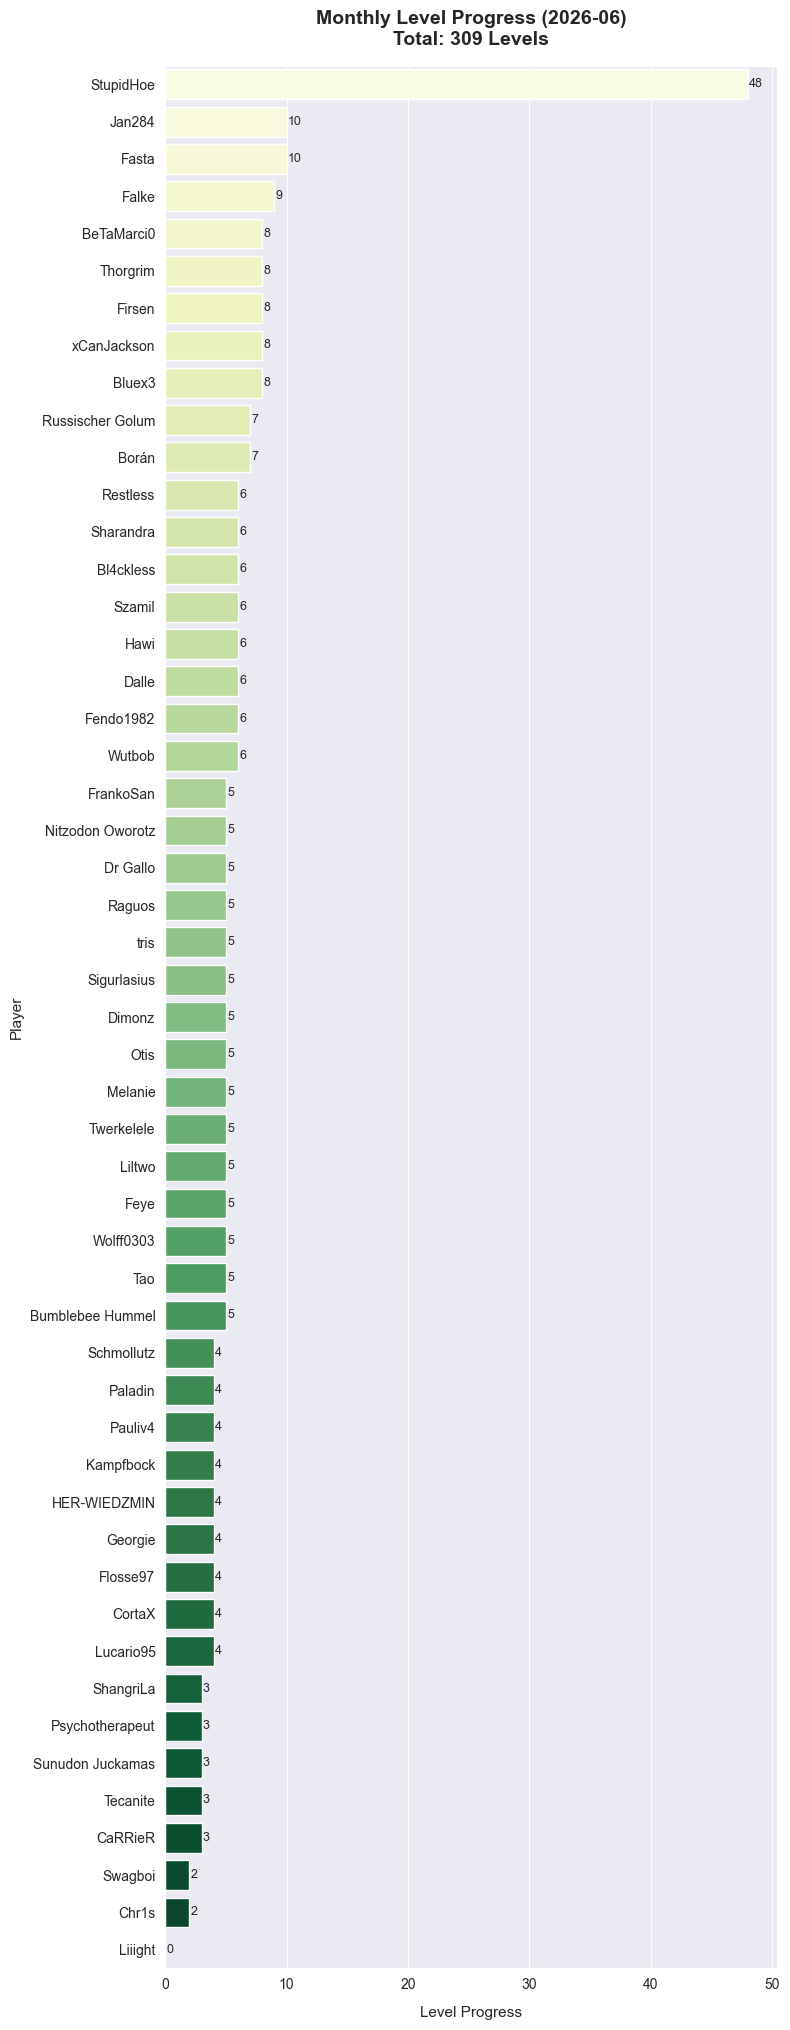

In [3]:
plot_data = final_monthly_df[['player_name', f'Monthly_Progress_{target_month}']].copy()
total_progress = plot_data[f'Monthly_Progress_{target_month}'].sum()

fig, ax = plt.subplots(figsize=(8, max(4, len(plot_data) * 0.4)))

sns.barplot(
    data=plot_data,
    x=f'Monthly_Progress_{target_month}',
    y='player_name',
    hue='player_name',
    palette='YlGn',
    legend=False,
    ax=ax
)

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center', ha='left', fontsize=9
    )

plt.title(f"Monthly Level Progress ({target_month})\nTotal: {int(total_progress)} Levels",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Level Progress", fontsize=11, labelpad=10)
plt.ylabel("Player", fontsize=11)
plt.tight_layout()

save_path = f"../visualizations/Q2_2026/monthly_analyses/monthly_level_progress_june_2026.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

New comers and leavers

In [4]:
all_players = set(pivot_df.index)

prev_month = (pd.to_datetime(target_month) - pd.DateOffset(months=1)).strftime('%Y-%m')
prev_month_cols = [w for w in weeks if w.strftime('%Y-%m') == prev_month]
target_month_cols = [w for w in weeks if w.strftime('%Y-%m') == target_month]

players_prev = set(pivot_df[prev_month_cols].dropna(how='all').index) if prev_month_cols else set()
players_target = set(pivot_df[target_month_cols].dropna(how='all').index) if target_month_cols else set()

left_players = players_prev - players_target

joined_players = players_target - players_prev

def last_seen(player):
    row = pivot_df.loc[player].dropna()
    return row.index[-1].strftime('%Y-%m-%d') if not row.empty else "unkown"

def first_seen(player):
    row = pivot_df.loc[player].dropna()
    return row.index[0].strftime('%Y-%m-%d') if not row.empty else "unkown"

left_df = pd.DataFrame({
    'player_name': sorted(left_players),
    'status': 'left this month',
    'date': [last_seen(p) for p in sorted(left_players)]
})

joined_df = pd.DataFrame({
    'player_name': sorted(joined_players),
    'status': 'joined this month',
    'date': [first_seen(p) for p in sorted(joined_players)]
})

movements_df = pd.concat([joined_df, left_df], ignore_index=True).sort_values('status')
print(movements_df.to_string(index=False))

player_name            status       date
      Dalle joined this month 2026-06-15
  Fendo1982 joined this month 2026-06-08
    Annatar   left this month 2026-05-11
     manekk   left this month 2026-05-18
